# Notebook — Teste do módulo `networks.py`

Este notebook testa o módulo:

```python
geodesy/networks.py
```

Serão testadas as funções:

- `normal_equations`
- `least_squares_adjustment`
- `covariance_of_parameters`
- `posterior_variance_factor`
- `error_ellipse_2d`

Os exemplos simulam ajustamento por mínimos quadrados, resíduos, matriz de covariância dos parâmetros e elipse de erro 2D.


In [1]:
# ============================================================
# 0. CONFIGURAÇÃO INICIAL
# ============================================================

import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

current_dir = Path.cwd()

if (current_dir / "geodesy").exists():
    sys.path.insert(0, str(current_dir))
    print("Pasta geodesy encontrada no diretório atual.")
else:
    print("Atenção: a pasta geodesy não foi encontrada no diretório atual.")

import geodesy
from geodesy import networks

print("Versão do pacote geodesy:", geodesy.__version__)


Pasta geodesy encontrada no diretório atual.
Versão do pacote geodesy: 0.1.0


## 1. Ajustamento linear simples


Parâmetros verdadeiros:
a = 10.0
b = 0.35

Parâmetros estimados:
a = 9.925926383614515
b = 0.3540928909339337

Primeiros resíduos:
[-0.68350778  2.0128317  -1.5611018  -1.93439174  3.85574517  2.56497091
 -0.2881318   0.60697129  0.01502552  1.69444817]


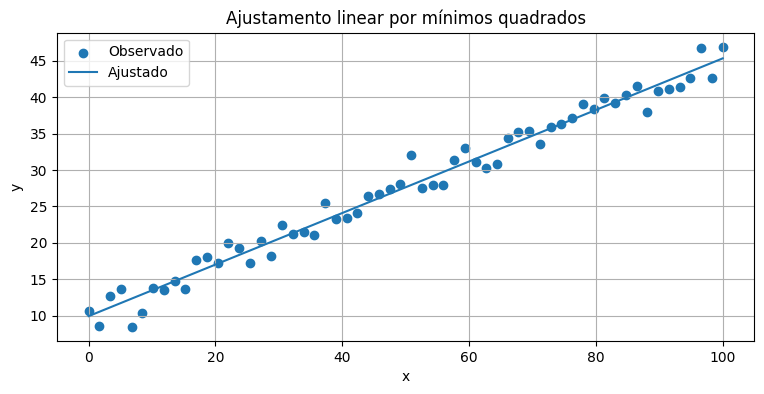

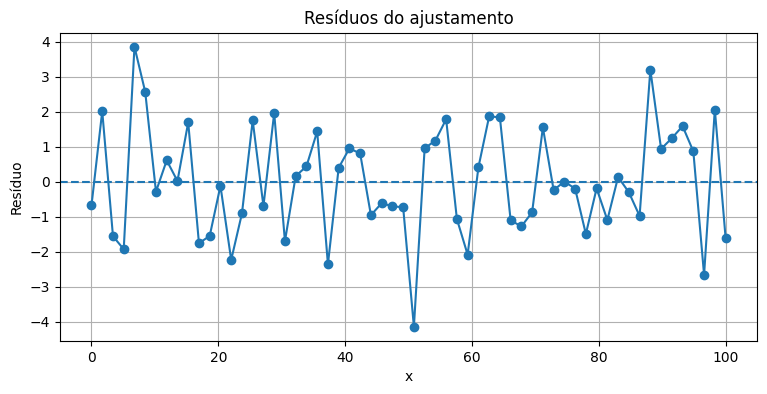

In [2]:
# ============================================================
# 1. AJUSTAMENTO LINEAR y = a + bx
# ============================================================

rng = np.random.default_rng(42)

x = np.linspace(0, 100, 60)
a_true = 10.0
b_true = 0.35

noise = rng.normal(0, 2.0, size=len(x))
y_obs = a_true + b_true*x + noise

A = np.column_stack([np.ones_like(x), x])
l = y_obs

x_hat, v, Nmat = networks.least_squares_adjustment(A, l)

a_est, b_est = x_hat

print("Parâmetros verdadeiros:")
print("a =", a_true)
print("b =", b_true)

print("\nParâmetros estimados:")
print("a =", a_est)
print("b =", b_est)

print("\nPrimeiros resíduos:")
print(v[:10])

y_fit = A @ x_hat

plt.figure(figsize=(9, 4))
plt.scatter(x, y_obs, label="Observado")
plt.plot(x, y_fit, label="Ajustado")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajustamento linear por mínimos quadrados")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(x, v, marker="o")
plt.axhline(0, linestyle="--")
plt.xlabel("x")
plt.ylabel("Resíduo")
plt.title("Resíduos do ajustamento")
plt.grid(True)
plt.show()


## 2. Equações normais


Matriz normal N:
[[6.00000000e+01 3.00000000e+03]
 [3.00000000e+03 2.01694915e+05]]

Vetor u:
[  1657.83425582 101196.51477989]

Solução via solve(N,u):
[9.92592638 0.35409289]


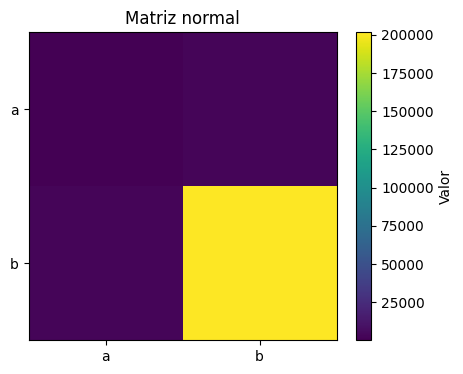

In [3]:
# ============================================================
# 2. EQUAÇÕES NORMAIS
# ============================================================

N_manual, u_manual = networks.normal_equations(A, l)

print("Matriz normal N:")
print(N_manual)

print("\nVetor u:")
print(u_manual)

print("\nSolução via solve(N,u):")
print(np.linalg.solve(N_manual, u_manual))

plt.figure(figsize=(5, 4))
plt.imshow(N_manual)
plt.colorbar(label="Valor")
plt.title("Matriz normal")
plt.xticks([0, 1], ["a", "b"])
plt.yticks([0, 1], ["a", "b"])
plt.show()


## 3. Fator de variância posterior e covariância dos parâmetros


In [4]:
# ============================================================
# 3. VARIÂNCIA E COVARIÂNCIA
# ============================================================

dof = len(l) - len(x_hat)

sigma0_2 = networks.posterior_variance_factor(v, dof=dof)
Cxx = networks.covariance_of_parameters(Nmat, sigma0_squared=sigma0_2)

print("Graus de liberdade:", dof)
print("Fator de variância posterior:", sigma0_2)

print("\nMatriz de covariância dos parâmetros:")
print(Cxx)

print("\nDesvios-padrão dos parâmetros:")
print(np.sqrt(np.diag(Cxx)))


Graus de liberdade: 58
Fator de variância posterior: 2.4966064309117333

Matriz de covariância dos parâmetros:
[[ 1.62347631e-01 -2.41475048e-03]
 [-2.41475048e-03  4.82950096e-05]]

Desvios-padrão dos parâmetros:
[0.40292385 0.00694946]


## 4. Elipse de erro 2D


Semi-eixo maior: 0.402968424215494
Semi-eixo menor: 0.0035178679129916532
Ângulo (rad): 3.1267186670973786
Ângulo (graus): 179.14778334945004


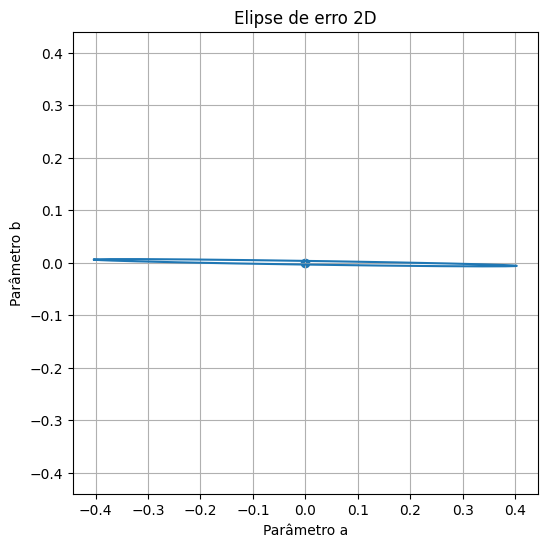

In [5]:
# ============================================================
# 4. ELIPSE DE ERRO
# ============================================================

major, minor, angle = networks.error_ellipse_2d(Cxx)

print("Semi-eixo maior:", major)
print("Semi-eixo menor:", minor)
print("Ângulo (rad):", angle)
print("Ângulo (graus):", np.rad2deg(angle))

theta = np.linspace(0, 2*np.pi, 300)

ellipse_x = major*np.cos(theta)
ellipse_y = minor*np.sin(theta)

R = np.array([
    [np.cos(angle), -np.sin(angle)],
    [np.sin(angle),  np.cos(angle)]
])

ellipse = R @ np.vstack([ellipse_x, ellipse_y])

plt.figure(figsize=(6, 6))
plt.plot(ellipse[0], ellipse[1])
plt.scatter([0], [0])
plt.xlabel("Parâmetro a")
plt.ylabel("Parâmetro b")
plt.title("Elipse de erro 2D")
plt.axis("equal")
plt.grid(True)
plt.show()


## 5. Ajustamento polinomial


Coeficientes verdadeiros: [ 3.  -1.5  0.7]
Coeficientes estimados: [ 2.69173135 -1.47728131  0.70398871]


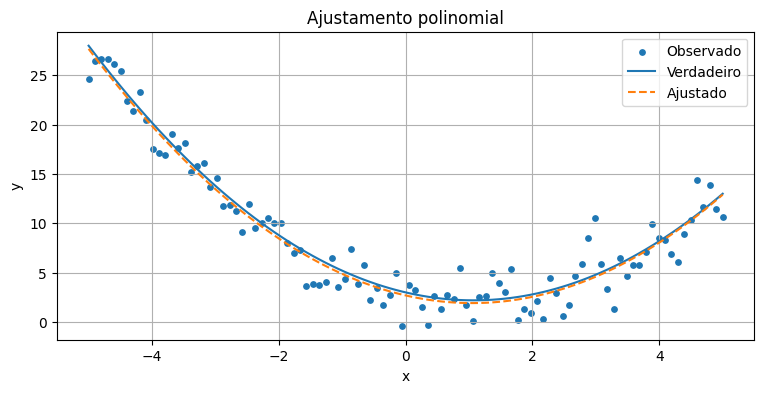

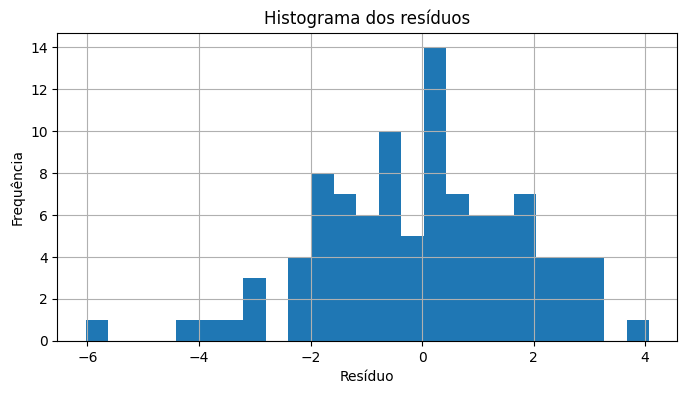

In [6]:
# ============================================================
# 5. AJUSTAMENTO POLINOMIAL
# ============================================================

x2 = np.linspace(-5, 5, 100)

coef_true = np.array([3.0, -1.5, 0.7])
y2_true = coef_true[0] + coef_true[1]*x2 + coef_true[2]*x2**2
y2_obs = y2_true + rng.normal(0, 2.0, size=len(x2))

A2 = np.column_stack([np.ones_like(x2), x2, x2**2])
coef_est, v2, N2 = networks.least_squares_adjustment(A2, y2_obs)

print("Coeficientes verdadeiros:", coef_true)
print("Coeficientes estimados:", coef_est)

y2_fit = A2 @ coef_est

plt.figure(figsize=(9, 4))
plt.scatter(x2, y2_obs, s=15, label="Observado")
plt.plot(x2, y2_true, label="Verdadeiro")
plt.plot(x2, y2_fit, linestyle="--", label="Ajustado")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Ajustamento polinomial")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(v2, bins=25)
plt.xlabel("Resíduo")
plt.ylabel("Frequência")
plt.title("Histograma dos resíduos")
plt.grid(True)
plt.show()


## 6. Ajustamento de superfície 2D


Coeficientes estimados:
[ 9.88484418  0.49719577 -0.27513533  0.20133303  0.10215124]


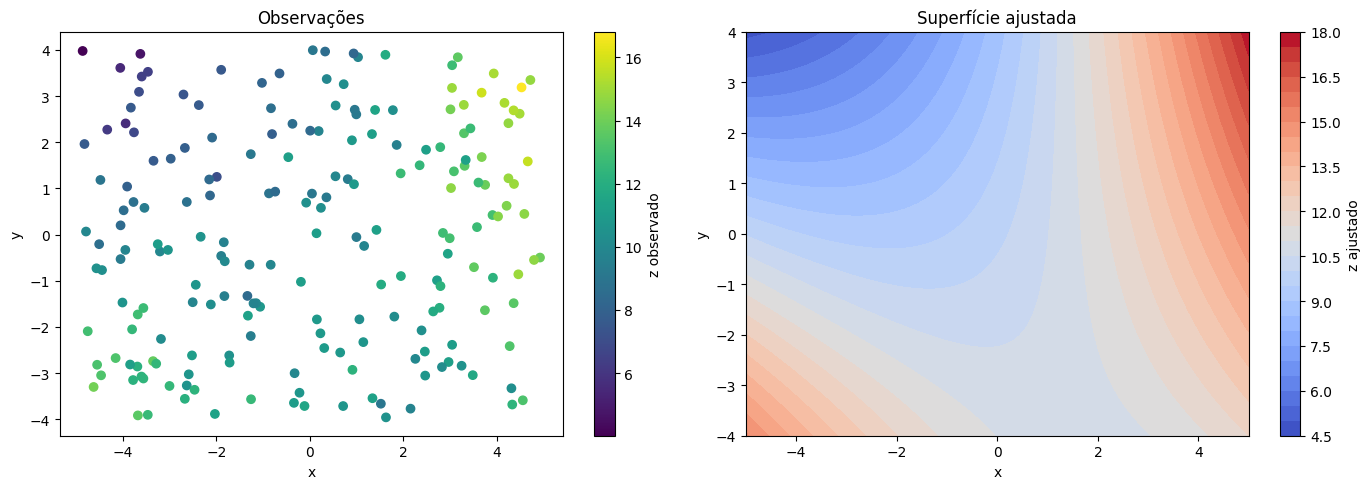

In [7]:
# ============================================================
# 6. AJUSTAMENTO DE SUPERFÍCIE 2D
# ============================================================

npts = 200

x_obs = rng.uniform(-5, 5, npts)
y_obs = rng.uniform(-4, 4, npts)

z_true = 10 + 0.5*x_obs - 0.3*y_obs + 0.2*x_obs*y_obs + 0.1*x_obs**2
z_obs = z_true + rng.normal(0, 0.8, npts)

A3 = np.column_stack([
    np.ones_like(x_obs),
    x_obs,
    y_obs,
    x_obs*y_obs,
    x_obs**2
])

coef3, v3, N3 = networks.least_squares_adjustment(A3, z_obs)

print("Coeficientes estimados:")
print(coef3)

xg = np.linspace(-5, 5, 80)
yg = np.linspace(-4, 4, 70)
XG, YG = np.meshgrid(xg, yg)

AG = np.column_stack([
    np.ones(XG.size),
    XG.ravel(),
    YG.ravel(),
    (XG*YG).ravel(),
    (XG**2).ravel()
])

ZG = (AG @ coef3).reshape(XG.shape)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
c1 = plt.scatter(x_obs, y_obs, c=z_obs)
plt.colorbar(c1, label="z observado")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Observações")

plt.subplot(1, 2, 2)
c2 = plt.contourf(XG, YG, ZG, cmap = "coolwarm", levels=30)
plt.colorbar(c2, label="z ajustado")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Superfície ajustada")

plt.tight_layout()
plt.show()


## 7. Resumo final


Se todas as células foram executadas sem erro, o módulo `networks.py` está funcionando corretamente.

O próximo notebook testa:

```python
geodesy/geodynamics.py
```
